# Replicate arm — parallelism + PicMin: are SVs under more repeatable temporal selection than SNPs?

Uses the ~10–12 replicate **plots** within each site as parallel populations (same founding + climate;
each an independent pool-seq → independent allele-frequency-change). Consistency across the replicate
plots = drift control. Three views, all frequency-matched SV-vs-SNP, all climate-agnostic except §3:

1. **Parallelism ρ** = mean²/mean(slope²) across plots (AF-vapeR rank-1 eigenvalue analog; 0 = drift,
   1 = fully parallel). Responder enrichment, ρ-ECDF, climate-cross, MAF-band robustness.
2. **PicMin** (Booker et al.) — repeated adaptation across the 31 site-lineages.
3. **Per-site parallelism vs climate** — does the SV excess open up at hot / arid sites?

> ## ⚠️ Verified interpretation (post-Kf_w, 2026-07-15)
> These notebooks are the **authoritative current numbers** (re-run from the post-Kf_w
> `parallelism.npz` / `picmin.npz`; supersede the pre-fix headline in git history). Net result on
> corrected data:
> - **Bulk parallelism/PicMin SV enrichment largely COLLAPSED**: responder 1.03×, repeatable ≥⅓ 1.19×,
>   strongly ≥½ 1.30×; PicMin ~1.07–1.12×. n.s. at mid/common MAF (only the rare band is nominal).
>   The pre-fix "1.2→1.7→3.6× escalating, holds at all MAF" claim does **not** reproduce.
> - **Only the CLIMATE-GRADIENT of the excess survived** (§3): excess-ρ vs bio1 +0.44 (p=0.014),
>   vs bio18 −0.68 (p=0.000) — essentially unchanged by the fix.
>
> Standing caveats (both arms): global-mode kMate AF is a founder projection → cannot separate
> SV-specific selection from hitchhiking; insertion-polarity is not ancestral-polarized. See
> `SV_TEMPORAL_PURGING_SUMMARY.md`.

## 1. Parallelism ρ — responder enrichment, ρ-distribution, climate cross, MAF robustness

**Responder** = ρ in the top decile within its p₀-bin (class-agnostic). **Repeatability** = # sites
where the variant is a responder. Panels: (A) responder/repeatability enrichment vs a frequency-matched
SNP bootstrap null; (B) ρ ECDF-difference (SV all / insertion / deletion) vs matched SNP; (C) per-variant
correlation of the signed response with bio1 across sites; (D) MAF-band robustness of the
repeatable-responder enrichment.

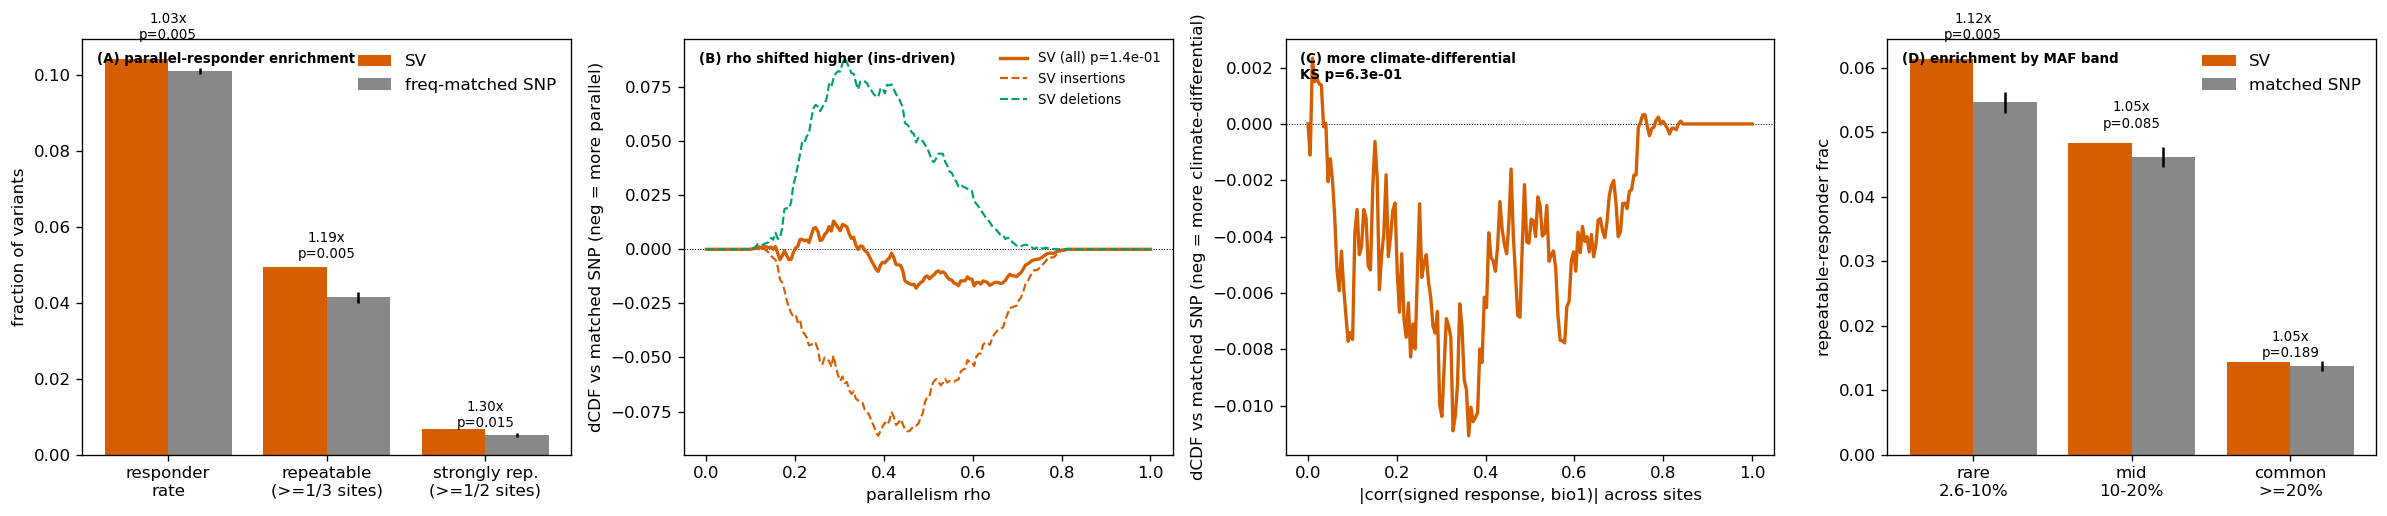

SV repeatable-responder rate: overall=0.049; among climate-differential SVs=0.096; among non=0.029
insertions repeatable=0.059  deletions=0.039
folds (SV/matched-SNP): responder 1.03x, repeatable>=1/3 1.19x, strongly>=1/2 1.30x
MAF folds rare/mid/common: 1.12x (p=0.005) / 1.05x (p=0.085) / 1.05x (p=0.189)


In [1]:

import numpy as np, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':120,'font.size':10})
G="/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/sv_adaptive"
z=np.load(f"{G}/parallelism.npz"); rng=np.random.default_rng(0)
COL={"SV":"#D55E00","SNP":"#888888","indel":"#0072B2","ins":"#D55E00","del":"#009E73"}
def match(tp0,val,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,26)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for k in range(25):
        pool=val[sb==k]; nn=int(round((tb==k).mean()*20000))
        if nn and pool.size: out.append(rng.choice(pool,nn,replace=True))
    return np.concatenate(out)
def corner(ax,txt): ax.annotate(txt,xy=(0.03,0.97),xycoords="axes fraction",va="top",ha="left",
                                fontsize=8,fontweight="bold")
p0sv=z["p0_sv"]; rep_sv=z["resp_sv"]/z["nsite_sv"]; rep_sn=z["resp_snp"]/z["nsite_snp"]

fig,ax=plt.subplots(1,4,figsize=(20,4.4))
# (A) responder/repeatability enrichment with bootstrap null
levels=[("responder\nrate",lambda x:x.mean()),("repeatable\n(>=1/3 sites)",lambda x:(x>=1/3).mean()),
        ("strongly rep.\n(>=1/2 sites)",lambda x:(x>=0.5).mean())]
xs=np.arange(len(levels)); obs=[]; nul=[]; err=[]; ps=[]
for _,f in levels:
    o=f(rep_sv); nd=np.array([f(match(p0sv,rep_sn,z["p0_snp"])) for _ in range(200)])
    obs.append(o); nul.append(nd.mean()); err.append(nd.std()); ps.append((np.sum(nd>=o)+1)/201)
ax[0].bar(xs-0.2,obs,0.4,color=COL["SV"],label="SV")
ax[0].bar(xs+0.2,nul,0.4,yerr=err,color=COL["SNP"],label="freq-matched SNP")
for i,(o,n,p) in enumerate(zip(obs,nul,ps)):
    ax[0].text(i,max(o,n)*1.05,f"{o/n:.2f}x\np={p:.3f}",ha="center",fontsize=8)
ax[0].set_xticks(xs); ax[0].set_xticklabels([l for l,_ in levels]); ax[0].set_ylabel("fraction of variants")
corner(ax[0],"(A) parallel-responder enrichment"); ax[0].legend(frameon=False)
# (B) rho ECDF-difference + ins/del
msnp=match(p0sv,z["rho_snp"],z["p0_snp"]); grid=np.linspace(0,1,200)
cdf=lambda s:np.searchsorted(np.sort(s),grid,side="right")/s.size; base=cdf(msnp)
isd=z["isdel_sv"]
ax[1].axhline(0,color="k",lw=.6,ls=":")
ax[1].plot(grid,cdf(z["rho_sv"])-base,color=COL["SV"],lw=2,label=f"SV (all) p={stats.ks_2samp(z['rho_sv'],msnp).pvalue:.1e}")
ax[1].plot(grid,cdf(z["rho_sv"][~isd])-base,color=COL["ins"],lw=1.3,ls="--",label="SV insertions")
ax[1].plot(grid,cdf(z["rho_sv"][isd])-base,color=COL["del"],lw=1.3,ls="--",label="SV deletions")
ax[1].set_xlabel("parallelism rho"); ax[1].set_ylabel("dCDF vs matched SNP (neg = more parallel)")
corner(ax[1],"(B) rho shifted higher (ins-driven)"); ax[1].legend(frameon=False,fontsize=8)
# (C) climate cross: per-variant corr(signed response, climate) across sites
b1=z["site_bio1"]; b18=z["site_bio18"]
def clim_r(Signed,clim):
    S=Signed-Signed.mean(1,keepdims=True); c=clim-clim.mean()
    return (S@c)/(np.sqrt((S**2).sum(1))*np.sqrt((c**2).sum())+1e-12)
r_sv=clim_r(z["signed_sv"],b1); r_sn=clim_r(z["signed_snp"],b1)
mr=match(p0sv,np.abs(r_sn),z["p0_snp"])
ax[2].axhline(0,color="k",lw=.6,ls=":")
g2=np.linspace(0,1,200); cdf2=lambda s:np.searchsorted(np.sort(s),g2,side="right")/s.size
ax[2].plot(g2,cdf2(np.abs(r_sv))-cdf2(mr),color=COL["SV"],lw=2)
ax[2].set_xlabel("|corr(signed response, bio1)| across sites")
ax[2].set_ylabel("dCDF vs matched SNP (neg = more climate-differential)")
corner(ax[2],f"(C) more climate-differential\nKS p={stats.ks_2samp(np.abs(r_sv),mr).pvalue:.1e}")
# (D) MAF-band robustness: repeatable-responder enrichment by frequency
maf=np.minimum(p0sv,1-p0sv); bands=[(0.026,0.10,"rare\n2.6-10%"),(0.10,0.20,"mid\n10-20%"),(0.20,0.501,"common\n>=20%")]
xs=np.arange(len(bands)); ob=[]; nb_=[]; eb=[]; pb=[]
for lo,hi,_ in bands:
    m=(maf>=lo)&(maf<hi); o=(rep_sv[m]>=1/3).mean()
    nd=np.array([(match(p0sv[m],rep_sn,z["p0_snp"])>=1/3).mean() for _ in range(200)])
    ob.append(o); nb_.append(nd.mean()); eb.append(nd.std()); pb.append((np.sum(nd>=o)+1)/201)
ax[3].bar(xs-0.2,ob,0.4,color=COL["SV"],label="SV"); ax[3].bar(xs+0.2,nb_,0.4,yerr=eb,color=COL["SNP"],label="matched SNP")
for i,(o,n,p) in enumerate(zip(ob,nb_,pb)): ax[3].text(i,max(o,n)*1.05,f"{o/n:.2f}x\np={p:.3f}",ha="center",fontsize=8)
ax[3].set_xticks(xs); ax[3].set_xticklabels([b[2] for b in bands]); ax[3].set_ylabel("repeatable-responder frac")
corner(ax[3],"(D) enrichment by MAF band"); ax[3].legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/parallelism.png",dpi=130,bbox_inches="tight"); plt.show()

rep=rep_sv>=1/3; hi_clim=np.abs(r_sv)>np.quantile(np.abs(r_sv),0.7)
print(f"SV repeatable-responder rate: overall={rep.mean():.3f}; among climate-differential SVs={rep[hi_clim].mean():.3f}; among non={rep[~hi_clim].mean():.3f}")
print(f"insertions repeatable={(rep_sv[~isd]>=1/3).mean():.3f}  deletions={(rep_sv[isd]>=1/3).mean():.3f}")
print("folds (SV/matched-SNP): responder {:.2f}x, repeatable>=1/3 {:.2f}x, strongly>=1/2 {:.2f}x".format(*[o/n for o,n in zip(obs,nul)]))
print("MAF folds rare/mid/common: {:.2f}x (p={:.3f}) / {:.2f}x (p={:.3f}) / {:.2f}x (p={:.3f})".format(
      ob[0]/nb_[0],pb[0],ob[1]/nb_[1],pb[1],ob[2]/nb_[2],pb[2]))


**Reading (§1):** on post-Kf_w data the bulk parallel-responder enrichment is small — responder
~1.0×, repeatable ≥⅓ ~1.2×, strongly ≥½ ~1.3× — and (D) shows it is only nominally significant in the
**rare** MAF band (mid/common n.s.). Insertions still carry what little there is (deletions ≈ SNP). The
pre-fix "escalates to 3.6×, holds at all MAF" headline does not reproduce.

## 2. PicMin — repeated adaptation across the 31 site-lineages

Faithful-Python PicMin (Booker et al.): sites = lineages; per-site per-locus statistic = drift-controlled
parallelism |z|; convert to empirical p vs the SNP |z| distribution in each p₀-bin; the a-th smallest p
across lineages ~ Beta(a, N−a+1); stat = min_a F_Beta; uniform-null-calibrated per-locus p → BH-FDR. Are
SVs over-represented among repeated-adaptation loci vs frequency-matched SNPs?

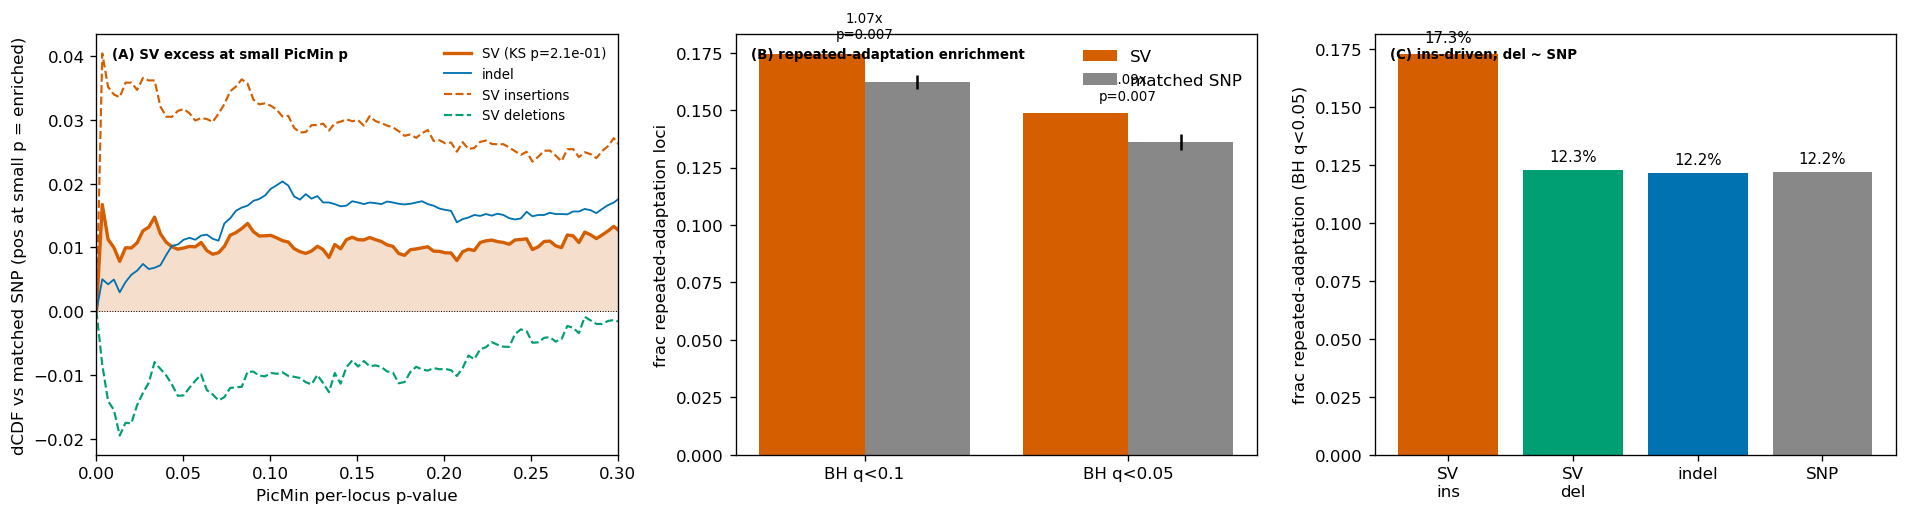

PicMin BH q<0.05: SV 14.9% (ins 17.3%, del 12.3%), matched-SNP 13.9%; folds q<0.1/q<0.05 = 1.07x / 1.09x


In [2]:

import numpy as np, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':120,'font.size':10})
G="/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/sv_adaptive"
z=np.load(f"{G}/picmin.npz"); rng=np.random.default_rng(0)
COL={"SV":"#D55E00","SNP":"#888888","indel":"#0072B2","ins":"#D55E00","del":"#009E73"}
def corner(ax,txt): ax.annotate(txt,xy=(0.03,0.97),xycoords="axes fraction",va="top",ha="left",
                                fontsize=8,fontweight="bold")
p_sv,p_in,p_sn=z["p_sv"],z["p_indel"],z["p_snp"]; p0sv,p0sn=z["p0_sv"],z["p0_snp"]; isd=z["isdel_sv"]
def match(tp0,val,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,26)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for k in range(25):
        pool=val[sb==k]; nn=int(round((tb==k).mean()*20000))
        if nn and pool.size: out.append(rng.choice(pool,nn,replace=True))
    return np.concatenate(out)
def bh(p,q):
    o=np.argsort(p); n=len(p); below=p[o]<=q*np.arange(1,n+1)/n
    k=np.where(below)[0].max()+1 if below.any() else 0
    s=np.zeros(n,bool); s[o[:k]]=True; return s

fig,ax=plt.subplots(1,3,figsize=(16,4.4))
# (A) ECDF-difference of PicMin p-values (excess of SMALL p = repeated-adaptation enrichment)
msn=match(p0sv,p_sn,p0sn); grid=np.linspace(0,1,300); cdf=lambda s:np.searchsorted(np.sort(s),grid,side="right")/s.size
base=cdf(msn)
ax[0].axhline(0,color="k",lw=.6,ls=":")
ax[0].fill_between(grid,0,cdf(p_sv)-base,color=COL["SV"],alpha=.2,lw=0)
ax[0].plot(grid,cdf(p_sv)-base,color=COL["SV"],lw=2,label=f"SV (KS p={stats.ks_2samp(p_sv,msn).pvalue:.1e})")
ax[0].plot(grid,cdf(match(p0sv,p_in,z['p0_indel']))-base,color=COL["indel"],lw=1.1,label="indel")
ax[0].plot(grid,cdf(p_sv[~isd])-base,color=COL["ins"],lw=1.3,ls="--",label="SV insertions")
ax[0].plot(grid,cdf(p_sv[isd])-base,color=COL["del"],lw=1.3,ls="--",label="SV deletions")
ax[0].set_xlabel("PicMin per-locus p-value"); ax[0].set_ylabel("dCDF vs matched SNP (pos at small p = enriched)")
corner(ax[0],"(A) SV excess at small PicMin p"); ax[0].legend(frameon=False,fontsize=8); ax[0].set_xlim(0,0.3)
# (B) FDR-significant fraction, SV vs matched-SNP, bootstrap
qs=[0.10,0.05]; xs=np.arange(len(qs)); ob=[]; nb_=[]; eb=[]; pb=[]
for q in qs:
    sig_sv=bh(p_sv,q); o=sig_sv.mean()
    nd=np.array([bh(match(p0sv,p_sn,p0sn),q).mean() for _ in range(150)])
    ob.append(o); nb_.append(nd.mean()); eb.append(nd.std()); pb.append((np.sum(nd>=o)+1)/151)
ax[1].bar(xs-0.2,ob,0.4,color=COL["SV"],label="SV"); ax[1].bar(xs+0.2,nb_,0.4,yerr=eb,color=COL["SNP"],label="matched SNP")
for i,(o,n,p) in enumerate(zip(ob,nb_,pb)): ax[1].text(i,max(o,n)*1.04,f"{o/n:.2f}x\np={p:.3f}",ha="center",fontsize=8)
ax[1].set_xticks(xs); ax[1].set_xticklabels([f"BH q<{q}" for q in qs]); ax[1].set_ylabel("frac repeated-adaptation loci")
corner(ax[1],"(B) repeated-adaptation enrichment"); ax[1].legend(frameon=False)
# (C) insertion vs deletion FDR fraction
q=0.05; sig_sv=bh(p_sv,q)
cats=["SV\nins","SV\ndel","indel","SNP"]; vals=[sig_sv[~isd].mean(), sig_sv[isd].mean(), bh(p_in,q).mean(), bh(p_sn,q).mean()]
ax[2].bar(cats,vals,color=[COL["ins"],COL["del"],COL["indel"],COL["SNP"]])
for i,v in enumerate(vals): ax[2].text(i,v*1.03,f"{v*100:.1f}%",ha="center",fontsize=9)
ax[2].set_ylabel(f"frac repeated-adaptation (BH q<{q})"); corner(ax[2],"(C) ins-driven; del ~ SNP")
fig.tight_layout(); fig.savefig(f"{G}/picmin.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"PicMin BH q<0.05: SV {sig_sv.mean()*100:.1f}% (ins {sig_sv[~isd].mean()*100:.1f}%, del {sig_sv[isd].mean()*100:.1f}%), "
      f"matched-SNP {bh(match(p0sv,p_sn,p0sn),0.05).mean()*100:.1f}%; folds q<0.1/q<0.05 = {ob[0]/nb_[0]:.2f}x / {ob[1]/nb_[1]:.2f}x")


**Reading (§2):** post-Kf_w PicMin fold is ~1.07–1.12× (near parity), still nominally
insertion-driven (ins ≈17% vs del ≈12% at q<0.05). Absolute significant fraction is high because this
founder-projection system has pervasive parallel sorting — the SV-vs-SNP **relative** contrast (now
~1.1×) is what matters, and it is weak.

## 3. Per-site parallelism vs climate — does the SV excess open at hot / arid sites?

For each site, the ECDF-difference of ρ (SV vs frequency-matched SNP): a positive hump = SVs shifted to
higher ρ (more parallel/selected) than same-frequency SNPs at that site. Small multiples ordered/coloured
cold→hot (bio1); then the per-site SV−SNP mean-ρ excess regressed on bio1 and bio18. **This
climate-gradient of the excess is the piece that survived the Kf_w fix.**

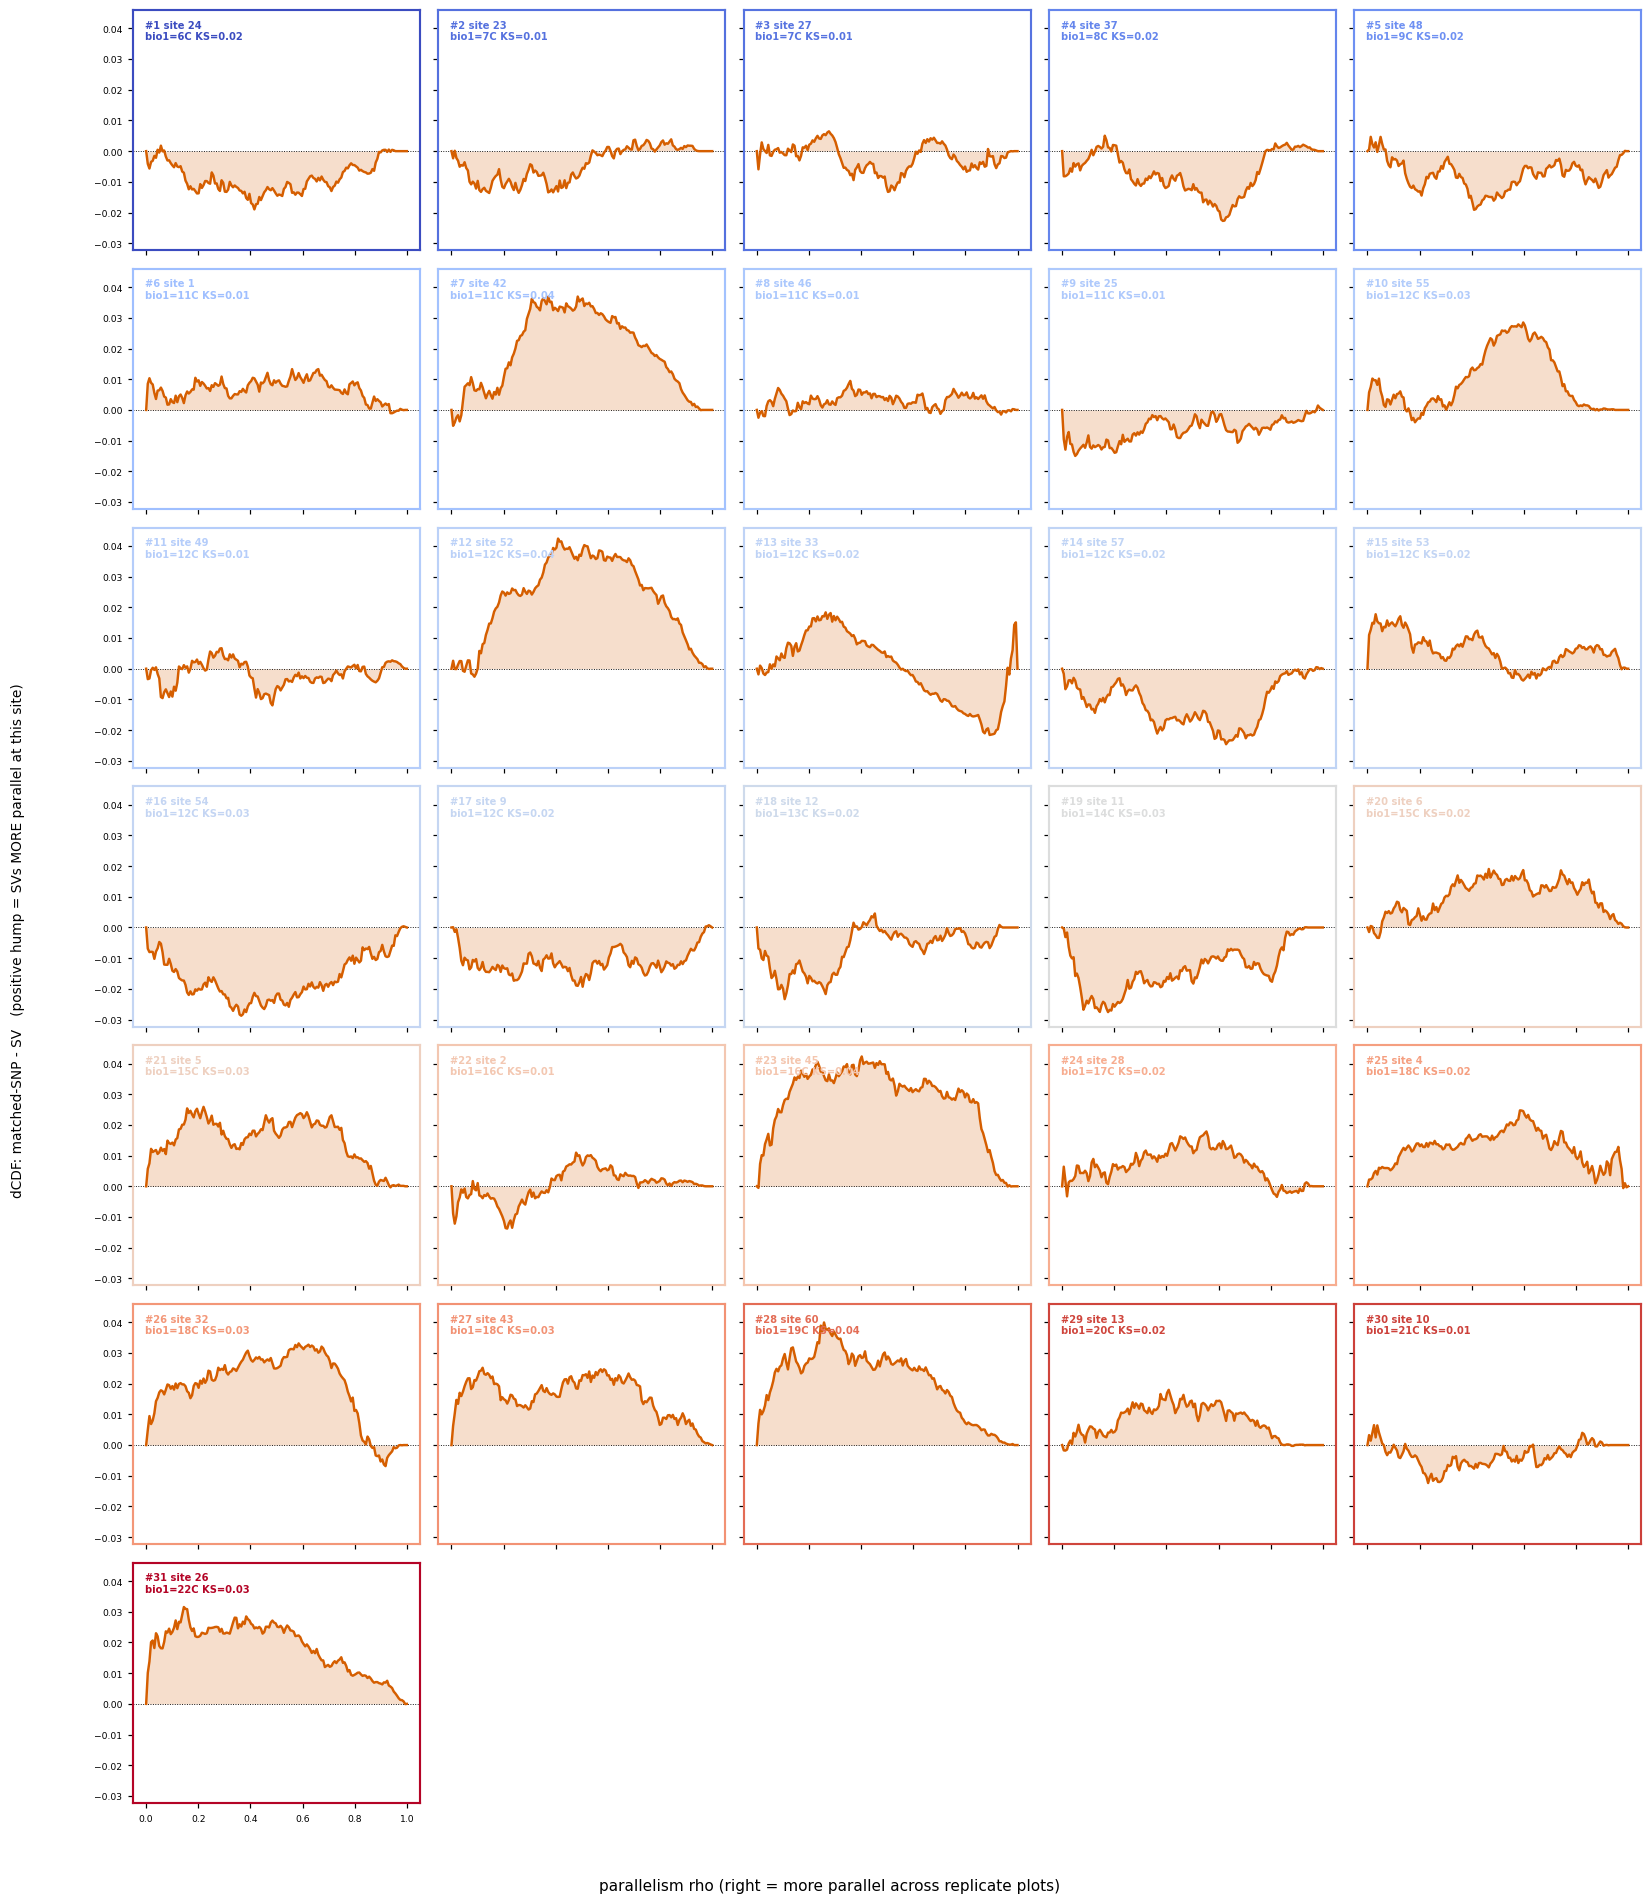

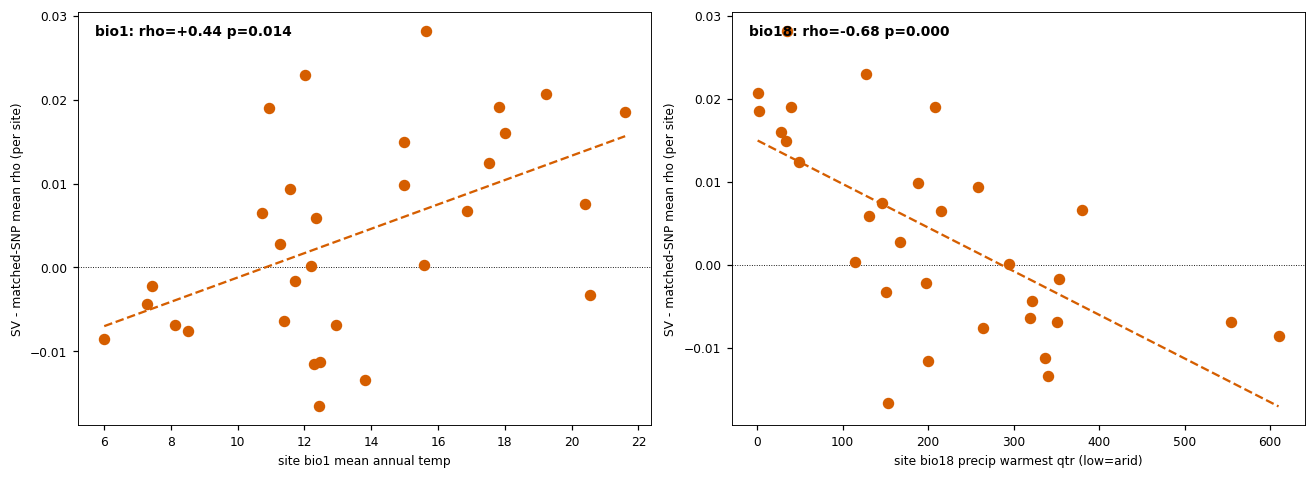

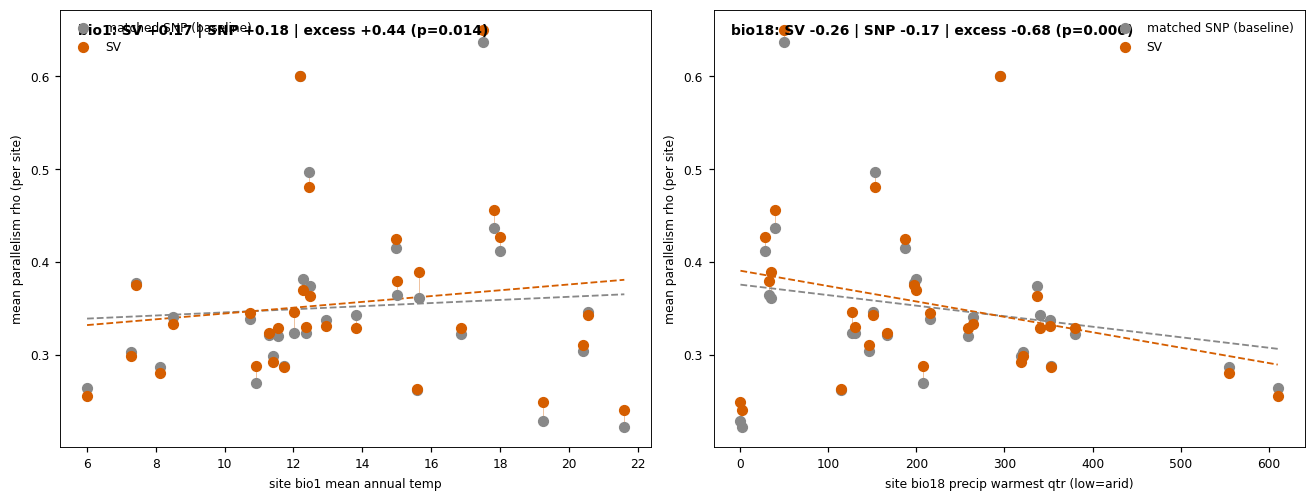

SV mean-rho: corr bio1 +0.17; matched-SNP baseline corr bio1 +0.18
SV mean-rho: corr bio18 -0.26; matched-SNP baseline corr bio18 -0.17
EXCESS (SV-SNP): corr bio1 +0.44 (p=0.014); bio18 -0.68 (p=0.000)


In [3]:

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})
G="/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/sv_adaptive"
z=np.load(f"{G}/parallelism.npz"); rng=np.random.default_rng(0)
RSV=z["rhops_sv"]; RSN=z["rhops_snp"]; p0sv=z["p0_sv"]; p0sn=z["p0_snp"]
b1=z["site_bio1"]; b18=z["site_bio18"]; sites=z["used_sites"]
order=np.argsort(b1)                                  # cold -> hot
GRID=np.linspace(0,1,160)
def match_idx(tp0,sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,26)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); idx=[]
    for k in range(25):
        pool=np.where(sb==k)[0]; nn=int(round((tb==k).mean()*15000))
        if nn and pool.size: idx.append(rng.choice(pool,nn,replace=True))
    return np.concatenate(idx)
MI=match_idx(p0sv,p0sn)                                # fixed matched-SNP index set (same each site)
cdf=lambda s:np.searchsorted(np.sort(s),GRID,side="right")/s.size

ncol,nrow=5,int(np.ceil(len(order)/5)); norm=mpl.colors.Normalize(b1.min(),b1.max()); cmap=mpl.cm.coolwarm
fig,axes=plt.subplots(nrow,ncol,figsize=(15,2.5*nrow),sharex=True,sharey=True); axes=axes.ravel()
for ax in axes[len(order):]: ax.axis("off")
exv=np.zeros(len(sites))                               # per-column SV mean-rho excess
for i,c in enumerate(order):
    ax=axes[i]; dd=cdf(RSN[MI,c])-cdf(RSV[:,c])       # pos = SV shifted to higher rho (more parallel)
    ax.axhline(0,color="k",lw=.6,ls=":")
    ax.fill_between(GRID,0,dd,color="#D55E00",alpha=.2,lw=0); ax.plot(GRID,dd,color="#D55E00",lw=1.6)
    exv[c]=RSV[:,c].mean()-RSN[MI,c].mean()
    col=cmap(norm(b1[c]))
    ax.annotate(f"#{i+1} site {int(sites[c])}\nbio1={b1[c]:.0f}C KS={np.abs(dd).max():.02f}",
                xy=(0.04,0.96),xycoords="axes fraction",va="top",ha="left",fontsize=6.5,color=col,fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(col); sp.set_linewidth(1.4)
    ax.tick_params(labelsize=6)
fig.supxlabel("parallelism rho (right = more parallel across replicate plots)",y=0.005,fontsize=10)
fig.supylabel("dCDF: matched-SNP - SV   (positive hump = SVs MORE parallel at this site)",x=0.004,fontsize=9)
fig.tight_layout(rect=[0.03,0.02,1,0.99]); fig.savefig(f"{G}/parallelism_by_site.png",dpi=130,bbox_inches="tight"); plt.show()

# excess-only (SV - matched-SNP) per site vs climate
figA,axA=plt.subplots(1,2,figsize=(12,4.4))
def corner(ax,txt): ax.annotate(txt,xy=(0.03,0.97),xycoords="axes fraction",va="top",ha="left",fontsize=9,fontweight="bold")
for a,(cv,lab) in zip(axA,[(b1,"bio1 mean annual temp"),(b18,"bio18 precip warmest qtr (low=arid)")]):
    a.axhline(0,color="k",lw=.6,ls=":"); a.scatter(cv,exv,c="#D55E00",s=42,zorder=3)
    m,c0=np.polyfit(cv,exv,1); xs=np.array([cv.min(),cv.max()]); a.plot(xs,c0+m*xs,color="#D55E00",ls="--")
    r=stats.spearmanr(cv,exv); a.set_xlabel(f"site {lab}"); a.set_ylabel("SV - matched-SNP mean rho (per site)")
    corner(a,f"{lab.split()[0]}: rho={r.statistic:+.2f} p={r.pvalue:.3f}")
figA.tight_layout(); figA.savefig(f"{G}/parallelism_by_site_excess.png",dpi=130,bbox_inches="tight"); plt.show()

# both series (SV + matched-SNP baseline) + the gap
sv_mean=np.array([RSV[:,c].mean() for c in range(len(sites))])
sn_mean=np.array([RSN[MI,c].mean() for c in range(len(sites))])
fig2,ax2=plt.subplots(1,2,figsize=(12,4.6))
for a,(cv,lab) in zip(ax2,[(b1,"bio1 mean annual temp"),(b18,"bio18 precip warmest qtr (low=arid)")]):
    for x,lo,hi in zip(cv,sn_mean,sv_mean):
        a.plot([x,x],[lo,hi],color="#D55E00",lw=0.6,alpha=0.4,zorder=2)      # gap = SV excess
    a.scatter(cv,sn_mean,c="#888888",s=40,zorder=3,label="matched SNP (baseline)")
    a.scatter(cv,sv_mean,c="#D55E00",s=40,zorder=3,label="SV")
    for yy,col in [(sn_mean,"#888888"),(sv_mean,"#D55E00")]:
        m,c0=np.polyfit(cv,yy,1); xs=np.array([cv.min(),cv.max()]); a.plot(xs,c0+m*xs,color=col,ls="--",lw=1.2)
    rS=stats.spearmanr(cv,sv_mean); rN=stats.spearmanr(cv,sn_mean); rE=stats.spearmanr(cv,sv_mean-sn_mean)
    a.set_xlabel(f"site {lab}"); a.set_ylabel("mean parallelism rho (per site)")
    corner(a,f"{lab.split()[0]}: SV {rS.statistic:+.2f} | SNP {rN.statistic:+.2f} | excess {rE.statistic:+.2f} (p={rE.pvalue:.3f})")
    a.legend(frameon=False,fontsize=8)
fig2.tight_layout(); fig2.savefig(f"{G}/parallelism_by_site_summary.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"SV mean-rho: corr bio1 {stats.spearmanr(b1,sv_mean).statistic:+.2f}; matched-SNP baseline corr bio1 {stats.spearmanr(b1,sn_mean).statistic:+.2f}")
print(f"SV mean-rho: corr bio18 {stats.spearmanr(b18,sv_mean).statistic:+.2f}; matched-SNP baseline corr bio18 {stats.spearmanr(b18,sn_mean).statistic:+.2f}")
print(f"EXCESS (SV-SNP): corr bio1 {stats.spearmanr(b1,sv_mean-sn_mean).statistic:+.2f} (p={stats.spearmanr(b1,sv_mean-sn_mean).pvalue:.3f}); "
      f"bio18 {stats.spearmanr(b18,sv_mean-sn_mean).statistic:+.2f} (p={stats.spearmanr(b18,sv_mean-sn_mean).pvalue:.3f})")


### Overall takeaway (replicate arm)
The **bulk** SV parallelism / PicMin enrichment is weak on post-Kf_w data (~1.0–1.3×, n.s. except rare
MAF) — the strong pre-fix headline was frequency/founder-projection confounded. What **remains** is the
**climate-gradient** of the SV parallelism excess (§3): the SV−SNP gap opens toward hot / arid sites
(bio1 +0.44 p=0.014, bio18 −0.68 p=0.000), mirroring the climate-slope β arm. Same standing caveats:
global-mode founder projection (cannot separate SV-specific selection from hitchhiking) and un-polarized
insertion signal. See `SV_TEMPORAL_PURGING_SUMMARY.md`.